In [1]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt


In [87]:
from sklearn.linear_model import LogisticRegression  
from sklearn.neighbors import KNeighborsClassifier  
from sklearn.svm import SVC 
from sklearn.tree import DecisionTreeClassifier 
from sklearn.ensemble import RandomForestClassifier
from lightgbm import LGBMClassifier
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.model_selection import train_test_split
from sklearn import preprocessing
from sklearn.metrics import accuracy_score
from xgboost import XGBClassifier
from sklearn.model_selection import KFold
from sklearn.model_selection import cross_val_score, GridSearchCV
from ydata_profiling import ProfileReport
import torch
from sklearn.metrics import f1_score
from sklearn.ensemble import RandomForestRegressor
from sklearn.feature_selection import SelectKBest, f_classif
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

In [17]:
from kaggle.api.kaggle_api_extended import KaggleApi
api = KaggleApi()
api.authenticate()

In [18]:
import warnings
warnings.filterwarnings("ignore", category=DeprecationWarning) 
warnings.filterwarnings("ignore", category=FutureWarning) 
warnings.filterwarnings("ignore", category=UserWarning) 

In [19]:
%config InlineBackend.figure_format = 'retina'


In [20]:
api.dataset_download_files('abdulwadood11220/netflix-customer-churn-dataset', path='.', unzip=True)


Dataset URL: https://www.kaggle.com/datasets/abdulwadood11220/netflix-customer-churn-dataset


In [21]:
df = pd.read_csv('netflix_customer_churn.csv',encoding='cp1252')

In [24]:
df.head()

,customer_id,age,gender,subscription_type,watch_hours,last_login_days,region,device,monthly_fee,churned,payment_method,number_of_profiles,avg_watch_time_per_day,favorite_genre
0,a9b75100-82a8-427a-a208-72f24052884a,51,Other,Basic,14.73,29,Africa,TV,8.99,1,Gift Card,1,0.49,Action
1,49a5dfd9-7e69-4022-a6ad-0a1b9767fb5b,47,Other,Standard,0.70,19,Europe,Mobile,13.99,1,Gift Card,5,0.03,Sci-Fi
2,4d71f6ce-fca9-4ff7-8afa-197ac24de14b,27,Female,Standard,16.32,10,Asia,TV,13.99,0,Crypto,2,1.48,Drama
3,d3c72c38-631b-4f9e-8a0e-de103cad1a7d,53,Other,Premium,4.51,12,Oceania,TV,17.99,1,Crypto,2,0.35,Horror
4,4e265c34-103a-4dbb-9553-76c9aa47e946,56,Other,Standard,1.89,13,Africa,Mobile,13.99,1,Crypto,2,0.13,Action


In [86]:
df['churned'].value_counts()

churned
1    2515
0    2485
Name: count, dtype: int64

In [10]:
df.describe()

,age,watch_hours,last_login_days,monthly_fee,churned,number_of_profiles,avg_watch_time_per_day
count,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000
mean,43.847400,11.649450,30.089800,13.683400,0.503000,3.024400,0.874800
std,15.501128,12.014654,17.536078,3.692062,0.500041,1.415841,2.619824
min,18.000000,0.010000,0.000000,8.990000,0.000000,1.000000,0.000000
25%,30.000000,3.337500,15.000000,8.990000,0.000000,2.000000,0.110000
50%,44.000000,8.000000,30.000000,13.990000,1.000000,3.000000,0.290000
75%,58.000000,16.030000,45.000000,17.990000,1.000000,4.000000,0.720000
max,70.000000,110.400000,60.000000,17.990000,1.000000,5.000000,98.420000


In [25]:
df.isna().sum()

customer_id               0
age                       0
gender                    0
subscription_type         0
watch_hours               0
last_login_days           0
region                    0
device                    0
monthly_fee               0
churned                   0
payment_method            0
number_of_profiles        0
avg_watch_time_per_day    0
favorite_genre            0
dtype: int64

In [26]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 14 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   customer_id             5000 non-null   object 
 1   age                     5000 non-null   int64  
 2   gender                  5000 non-null   object 
 3   subscription_type       5000 non-null   object 
 4   watch_hours             5000 non-null   float64
 5   last_login_days         5000 non-null   int64  
 6   region                  5000 non-null   object 
 7   device                  5000 non-null   object 
 8   monthly_fee             5000 non-null   float64
 9   churned                 5000 non-null   int64  
 10  payment_method          5000 non-null   object 
 11  number_of_profiles      5000 non-null   int64  
 12  avg_watch_time_per_day  5000 non-null   float64
 13  favorite_genre          5000 non-null   object 
dtypes: float64(3), int64(4), object(7)
memor

In [27]:
df=df.drop(columns=['customer_id'])

In [28]:
df.head()

,age,gender,subscription_type,watch_hours,last_login_days,region,device,monthly_fee,churned,payment_method,number_of_profiles,avg_watch_time_per_day,favorite_genre
0,51,Other,Basic,14.73,29,Africa,TV,8.99,1,Gift Card,1,0.49,Action
1,47,Other,Standard,0.70,19,Europe,Mobile,13.99,1,Gift Card,5,0.03,Sci-Fi
2,27,Female,Standard,16.32,10,Asia,TV,13.99,0,Crypto,2,1.48,Drama
3,53,Other,Premium,4.51,12,Oceania,TV,17.99,1,Crypto,2,0.35,Horror
4,56,Other,Standard,1.89,13,Africa,Mobile,13.99,1,Crypto,2,0.13,Action


In [13]:
report=ProfileReport(df)
report.to_file('data_report.html')

Summarize dataset:   0%|          | 0/5 [00:00<?, ?it/s]


100%|█████████████████████████████████████████████████████████████████████████████████| 13/13 [00:00<00:00, 177.95it/s]


Generate report structure:   0%|          | 0/1 [00:00<?, ?it/s]

Render HTML:   0%|          | 0/1 [00:00<?, ?it/s]

Export report to file:   0%|          | 0/1 [00:00<?, ?it/s]

In [14]:
df.head()

,age,gender,subscription_type,watch_hours,last_login_days,region,device,monthly_fee,churned,payment_method,number_of_profiles,avg_watch_time_per_day,favorite_genre
0,51,Other,Basic,14.73,29,Africa,TV,8.99,1,Gift Card,1,0.49,Action
1,47,Other,Standard,0.70,19,Europe,Mobile,13.99,1,Gift Card,5,0.03,Sci-Fi
2,27,Female,Standard,16.32,10,Asia,TV,13.99,0,Crypto,2,1.48,Drama
3,53,Other,Premium,4.51,12,Oceania,TV,17.99,1,Crypto,2,0.35,Horror
4,56,Other,Standard,1.89,13,Africa,Mobile,13.99,1,Crypto,2,0.13,Action


<Axes: xlabel='churned', ylabel='count'>

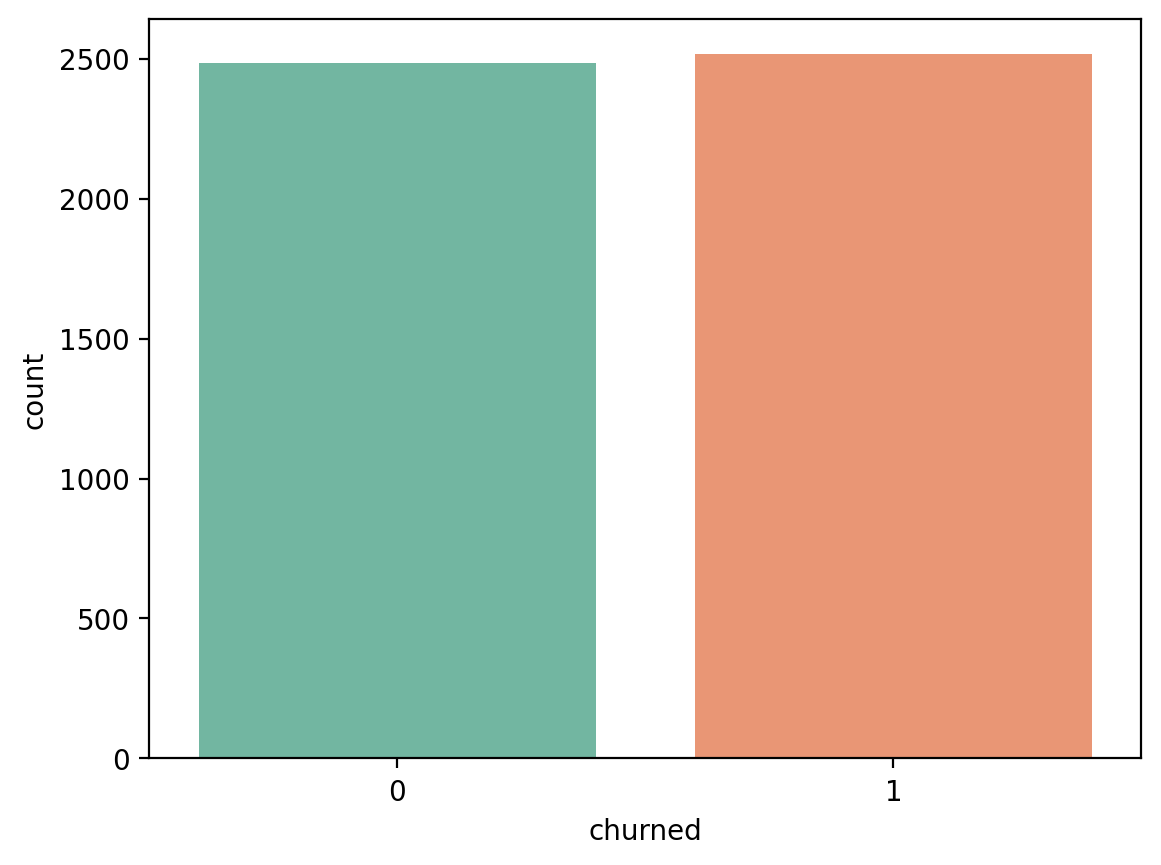

In [29]:
sns.countplot(data=df, x=df['churned'], palette='Set2')

<Axes: xlabel='gender', ylabel='count'>

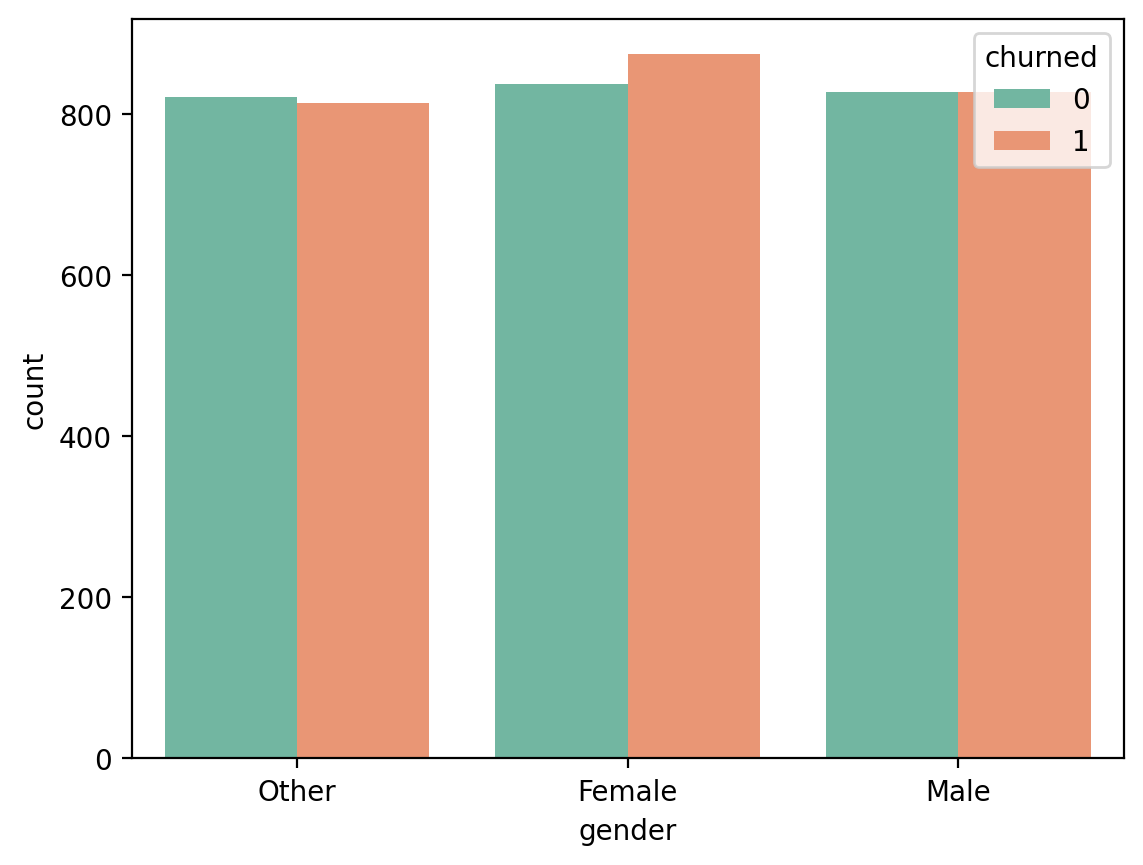

In [16]:
sns.countplot(data=df,hue=df['churned'],x=df['gender'],palette = 'Set2')

<Axes: xlabel='subscription_type', ylabel='count'>

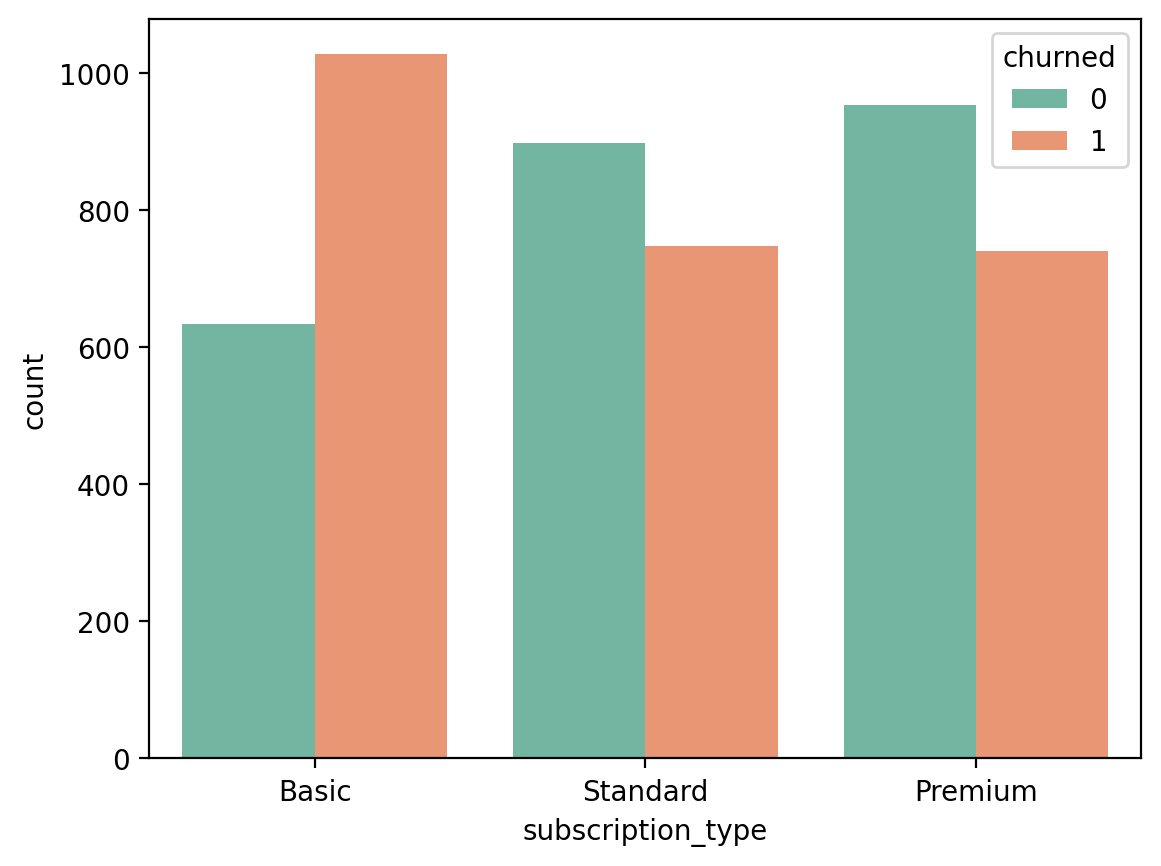

In [17]:
sns.countplot(data=df,hue=df['churned'],x=df['subscription_type'],palette = 'Set2')

In [22]:
sns.countplot(data=df, x='churned', palette='Set2')

<Axes: xlabel='churned', ylabel='count'>

In [19]:
print(df['churned'].value_counts())

churned
1    2515
0    2485
Name: count, dtype: int64


In [24]:
print(dt['watch_hours'].dtype)
print(dt['monthly_fee'].dtype)

float64
float64


In [28]:
print(df['churned'].unique())

[1 0]


In [31]:
print(dt['monthly_fee'].unique())

[ 8.99 13.99 17.99]


In [59]:
X=df.drop(columns='churned')
y=df['churned']

In [60]:
X_encoded = pd.get_dummies(X, columns=['gender', 'subscription_type', 'region', 'device', 'payment_method', 'favorite_genre'])


In [61]:
X_encoded.head()

,age,watch_hours,last_login_days,monthly_fee,number_of_profiles,avg_watch_time_per_day,gender_Female,gender_Male,gender_Other,subscription_type_Basic,...,payment_method_Debit Card,payment_method_Gift Card,payment_method_PayPal,favorite_genre_Action,favorite_genre_Comedy,favorite_genre_Documentary,favorite_genre_Drama,favorite_genre_Horror,favorite_genre_Romance,favorite_genre_Sci-Fi
0,51,14.73,29,8.99,1,0.49,False,False,True,True,...,False,True,False,True,False,False,False,False,False,False
1,47,0.70,19,13.99,5,0.03,False,False,True,False,...,False,True,False,False,False,False,False,False,False,True
2,27,16.32,10,13.99,2,1.48,True,False,False,False,...,False,False,False,False,False,False,True,False,False,False
3,53,4.51,12,17.99,2,0.35,False,False,True,False,...,False,False,False,False,False,False,False,True,False,False
4,56,1.89,13,13.99,2,0.13,False,False,True,False,...,False,False,False,True,False,False,False,False,False,False


In [77]:
X_encoded.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 35 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   age                         5000 non-null   int64  
 1   watch_hours                 5000 non-null   float64
 2   last_login_days             5000 non-null   int64  
 3   monthly_fee                 5000 non-null   float64
 4   number_of_profiles          5000 non-null   int64  
 5   avg_watch_time_per_day      5000 non-null   float64
 6   gender_Female               5000 non-null   bool   
 7   gender_Male                 5000 non-null   bool   
 8   gender_Other                5000 non-null   bool   
 9   subscription_type_Basic     5000 non-null   bool   
 10  subscription_type_Premium   5000 non-null   bool   
 11  subscription_type_Standard  5000 non-null   bool   
 12  region_Africa               5000 non-null   bool   
 13  region_Asia                 5000 

In [58]:

selector=SelectKBest(f_classif,k=2)
selector.fit(X_encoded,y)
important_features=selector.get_support(indices=True)


In [16]:
important_features = X_encoded.columns[selector.get_support()]
print(important_features)

Index(['watch_hours', 'last_login_days'], dtype='object')


In [93]:
X = X_encoded
y = df["churned"]

In [94]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y , test_size=0.3, random_state=42)

In [95]:
from sklearn.preprocessing import StandardScaler

scaler=StandardScaler()
X_train = scaler.fit_transform(X_train)

In [96]:
from sklearn.linear_model import LogisticRegression
lr=LogisticRegression()
lr.fit(X_train,y_train) 

,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :term:`mul

In [97]:
import torch
from sklearn.metrics import f1_score

In [98]:
y_pred=lr.predict(X_test)
from sklearn.metrics import accuracy_score, precision_score, recall_score


In [100]:
print("accuracy:", accuracy_score(y_test, y_pred))
print("precision:", precision_score(y_test, y_pred, average="weighted"))
print("recall:",recall_score(y_test,y_pred,average="weighted"))
print("f1 score:", f1_score(y_test,y_pred,average="weighted"))

accuracy: 0.8313333333333334
precision: 0.8514769681143278
recall: 0.8313333333333334
f1 score: 0.8289806605284245


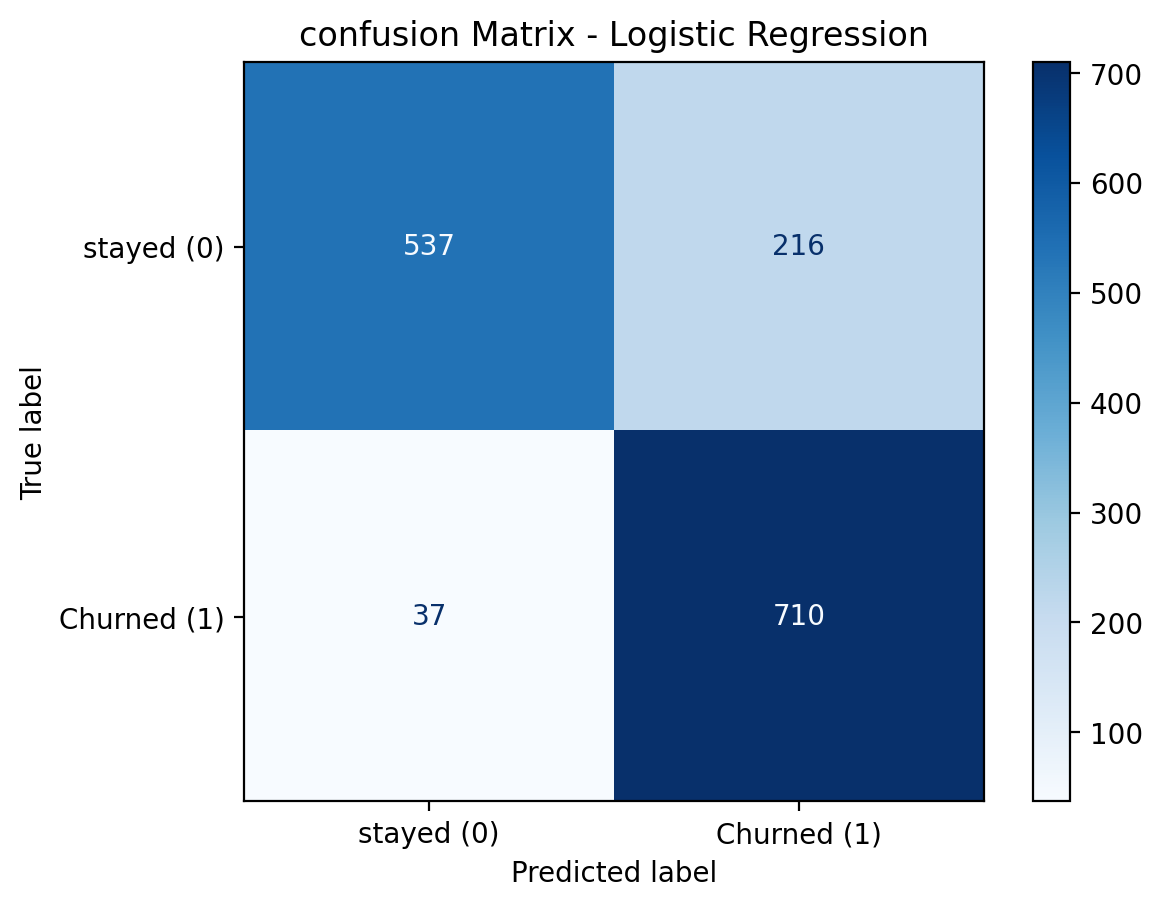

confusion matrix:
[[537 216]
 [ 37 710]]


In [99]:
cm=confusion_matrix(y_test,y_pred)
disp=ConfusionMatrixDisplay(confusion_matrix=cm,display_labels=['stayed (0)','Churned (1)'])
disp.plot(cmap='Blues')
plt.title("confusion Matrix - Logistic Regression")
plt.show()
print("confusion matrix:")
print(cm)

X shape: (5000, 35)
Columns in X: ['age', 'watch_hours', 'last_login_days', 'monthly_fee', 'number_of_profiles', 'avg_watch_time_per_day', 'gender_Female', 'gender_Male', 'gender_Other', 'subscription_type_Basic', 'subscription_type_Premium', 'subscription_type_Standard', 'region_Africa', 'region_Asia', 'region_Europe', 'region_North America', 'region_Oceania', 'region_South America', 'device_Desktop', 'device_Laptop', 'device_Mobile', 'device_TV', 'device_Tablet', 'payment_method_Credit Card', 'payment_method_Crypto', 'payment_method_Debit Card', 'payment_method_Gift Card', 'payment_method_PayPal', 'favorite_genre_Action', 'favorite_genre_Comedy', 'favorite_genre_Documentary', 'favorite_genre_Drama', 'favorite_genre_Horror', 'favorite_genre_Romance', 'favorite_genre_Sci-Fi']
X_train type: <class 'pandas.core.frame.DataFrame'>
X_train columns: ['age', 'watch_hours', 'last_login_days', 'monthly_fee', 'number_of_profiles', 'avg_watch_time_per_day', 'gender_Female', 'gender_Male', 'gender

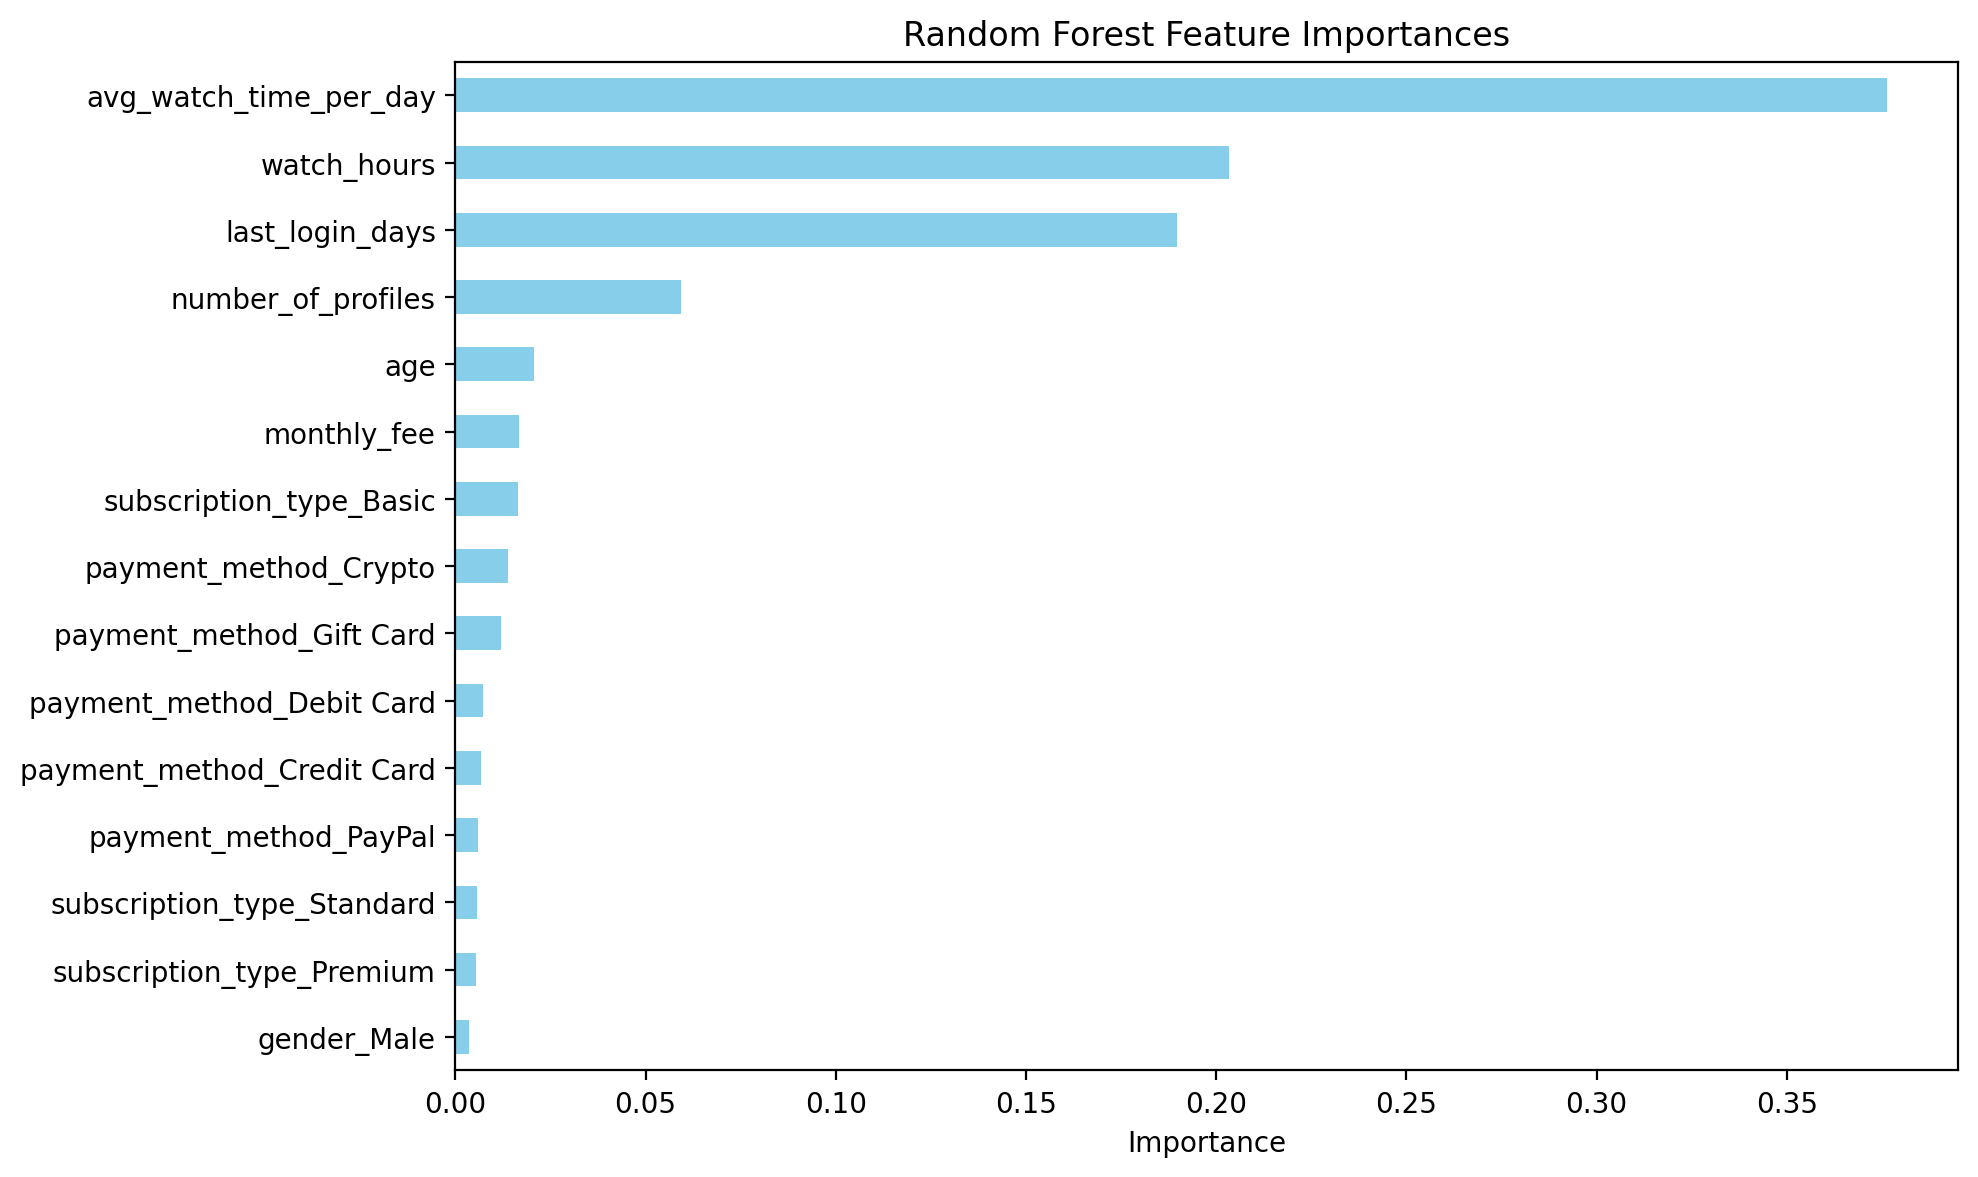

In [ ]:
# ───────────────────────────────────────────────────────────────
# 1. Prepare X and y from your encoded DataFrame
# ───────────────────────────────────────────────────────────────

# X should contain all features (35 columns), y is the target
X = X_encoded.copy()           # or X = X_encoded.drop(columns=['churned']) if churned is still in it
y = df['churned']              # or however you defined y earlier

# Make sure X is a DataFrame (very important for .columns later)
print("X shape:", X.shape)
print("Columns in X:", X.columns.tolist())

# ───────────────────────────────────────────────────────────────
# 2. Train-test split (keep as DataFrame)
# ───────────────────────────────────────────────────────────────

from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.3,
    random_state=42,
    stratify=y               # recommended for slightly imbalanced classes
)

# Confirm it's still DataFrame
print("X_train type:", type(X_train))
print("X_train columns:", X_train.columns.tolist())

# ───────────────────────────────────────────────────────────────
# 3. Random Forest Classifier
# ───────────────────────────────────────────────────────────────

from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, f1_score, classification_report

rf = RandomForestClassifier(
    n_estimators=200,          # number of trees
    max_depth=None,            # None = grow until pure leaves (default good start)
    min_samples_split=5,
    min_samples_leaf=2,
    max_features='sqrt',       # or 'log2' or 0.3–0.5 — try if overfitting
    random_state=42,
    n_jobs=-1                  # use all cores
)

rf.fit(X_train, y_train)

# ───────────────────────────────────────────────────────────────
# 4. Predictions & evaluation
# ───────────────────────────────────────────────────────────────

y_pred = rf.predict(X_test)
y_pred_proba = rf.predict_proba(X_test)[:, 1]  # probability of churn (class 1)

print("Accuracy:          ", round(accuracy_score(y_test, y_pred), 4))
print("F1 (weighted):     ", round(f1_score(y_test, y_pred, average='weighted'), 4))
print("F1 (macro):        ", round(f1_score(y_test, y_pred, average='macro'), 4))
print("\nClassification Report:\n")
print(classification_report(y_test, y_pred, digits=4))


# 5. Feature importances – now safe because X_train is DataFrame


import pandas as pd

importances = pd.Series(
    rf.feature_importances_,
    index=X_train.columns
).sort_values(ascending=False)

print("\nTop 12 most important features:\n")
print(importances.head(12))

# Optional: plot the top features
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))
importances.head(15).plot(kind='barh', color='skyblue')
plt.title('Random Forest Feature Importances')
plt.xlabel('Importance')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

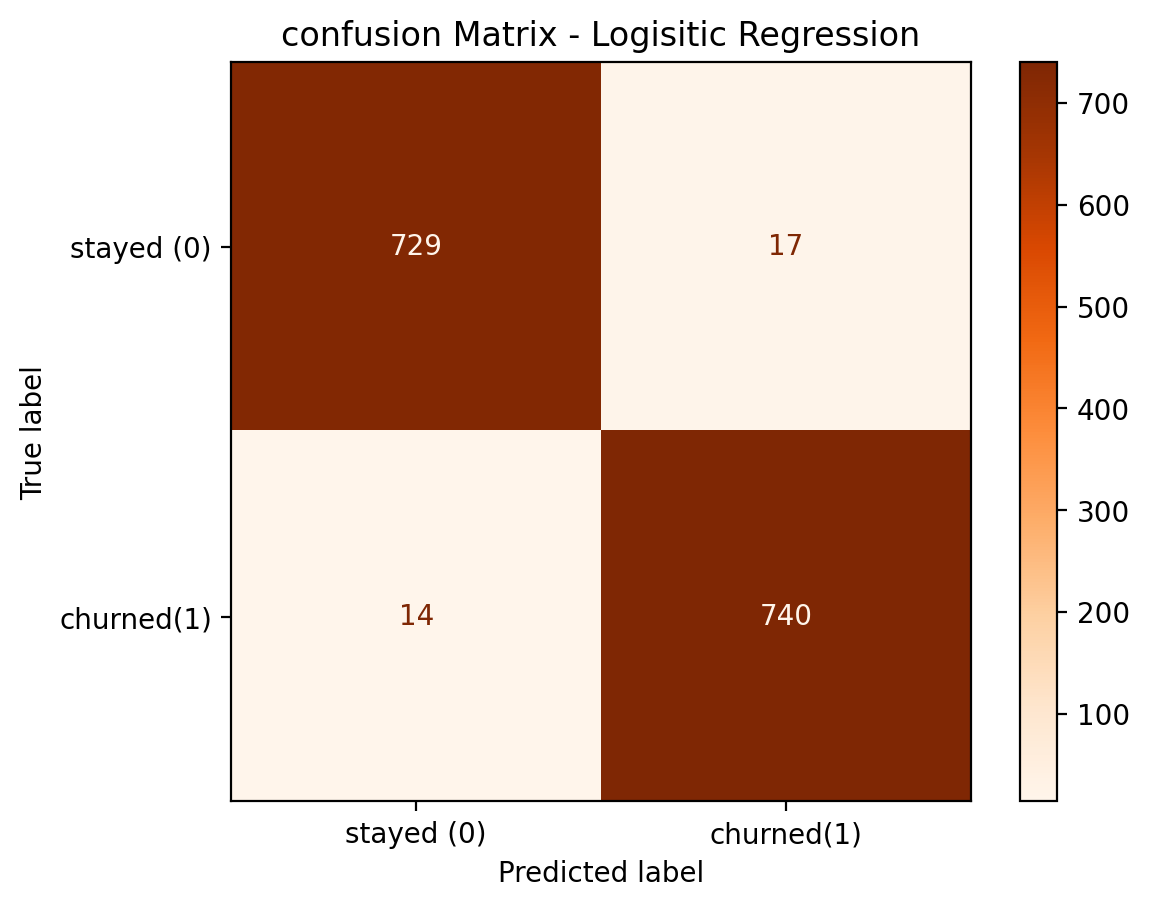

confusion matrix:
[[729  17]
 [ 14 740]]


In [ ]:
cm=confusion_matrix(y_test,y_pred)
disp=ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['stayed (0)','churned(1)'])
disp.plot(cmap='Oranges')
plt.title("confusion Matrix - Random Forest")
plt.show()
print("confusion matrix:")
print(cm)

In [80]:
probs = rf.predict_proba(X_test)[:, 1]

In [81]:
import numpy as np
from sklearn.metrics import confusion_matrix

thresholds = np.arange(0,1,0.01)
#Generate numbers starting at 0
#Stop before 1
#Step by 0.01
results = []

for t in thresholds:
    preds = (probs >= t).astype(int)
    tn, fp, fn, tp = confusion_matrix(y_test, preds).ravel()
    f1 = f1_score(y_test, preds)
    results.append([t, tn, fp, fn, tp])

In [82]:
results

[[np.float64(0.0), np.int64(0), np.int64(746), np.int64(0), np.int64(754)],
 [np.float64(0.01), np.int64(35), np.int64(711), np.int64(0), np.int64(754)],
 [np.float64(0.02), np.int64(93), np.int64(653), np.int64(0), np.int64(754)],
 [np.float64(0.03), np.int64(181), np.int64(565), np.int64(0), np.int64(754)],
 [np.float64(0.04), np.int64(243), np.int64(503), np.int64(0), np.int64(754)],
 [np.float64(0.05), np.int64(293), np.int64(453), np.int64(0), np.int64(754)],
 [np.float64(0.06), np.int64(327), np.int64(419), np.int64(0), np.int64(754)],
 [np.float64(0.07), np.int64(353), np.int64(393), np.int64(0), np.int64(754)],
 [np.float64(0.08), np.int64(388), np.int64(358), np.int64(0), np.int64(754)],
 [np.float64(0.09), np.int64(411), np.int64(335), np.int64(0), np.int64(754)],
 [np.float64(0.1), np.int64(433), np.int64(313), np.int64(0), np.int64(754)],
 [np.float64(0.11), np.int64(450), np.int64(296), np.int64(0), np.int64(754)],
 [np.float64(0.12), np.int64(465), np.int64(281), np.int64

In [83]:
from sklearn.metrics import f1_score

best_f1 = 0
best_t = 0

for t in thresholds:
    preds = (probs >= t).astype(int)
    f1 = f1_score(y_test, preds)
    if f1 > best_f1:
        best_f1 = f1
        best_t = t

print(best_t, best_f1)

0.51 0.9800796812749004


In [84]:
results = []

for t in thresholds:
    preds = (probs >= t).astype(int)
    tn, fp, fn, tp = confusion_matrix(y_test, preds).ravel()
    f1 = f1_score(y_test, preds)
    results.append([t, tn, fp, fn, tp, f1])

best = max(results, key=lambda x: x[5])
print(best)

[np.float64(0.51), np.int64(732), np.int64(14), np.int64(16), np.int64(738), 0.9800796812749004]


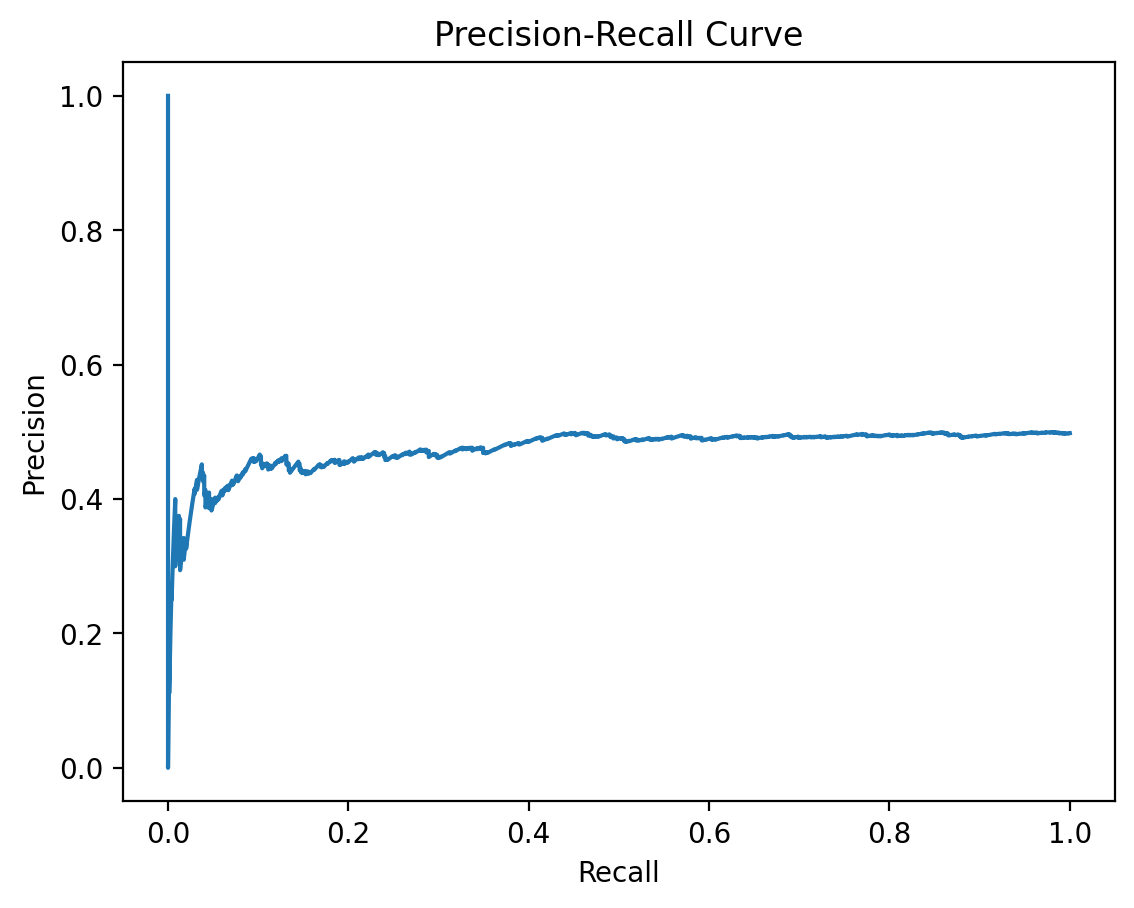

In [101]:
from sklearn.metrics import precision_recall_curve
import matplotlib.pyplot as plt

precision, recall, thresholds = precision_recall_curve(y_test, probs)

plt.plot(recall, precision)
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision-Recall Curve")
plt.show()

In [105]:
from sklearn.metrics import precision_recall_curve
import pandas as pd
y_pred = rf.predict(X_test)
precision, recall, thresholds = precision_recall_curve(y_test, y_pred_proba)

# Create nice table
pr_df = pd.DataFrame({
    'threshold': thresholds,
    'precision': precision[:-1],   # last value is always 1
    'recall':    recall[:-1]
})

# Show interesting parts
print("Precision-Recall values at different thresholds:")
print(pr_df.round(3))

# Or show only higher recall / precision regions
print("\nTop rows where recall ≥ 0.7:")
print(pr_df[pr_df['recall'] >= 0.7].round(3))

print("\nRows where precision ≥ 0.9:")
print(pr_df[pr_df['precision'] >= 0.9].round(3))

Precision-Recall values at different thresholds:
      threshold  precision  recall
0         0.000      0.498   1.000
1         0.001      0.498   0.999
2         0.001      0.498   0.999
3         0.002      0.498   0.997
4         0.002      0.497   0.996
...         ...        ...     ...
1489      0.995      0.167   0.001
1490      0.996      0.000   0.000
1491      0.996      0.000   0.000
1492      0.997      0.000   0.000
1493      0.999      0.000   0.000

[1494 rows x 3 columns]

Top rows where recall ≥ 0.7:
     threshold  precision  recall
0        0.000      0.498   1.000
1        0.001      0.498   0.999
2        0.001      0.498   0.999
3        0.002      0.498   0.997
4        0.002      0.497   0.996
..         ...        ...     ...
429      0.099      0.492   0.703
430      0.101      0.491   0.701
431      0.101      0.492   0.701
432      0.102      0.491   0.700
433      0.102      0.492   0.700

[434 rows x 3 columns]

Rows where precision ≥ 0.9:
Empty DataFrame

In [106]:
df.groupby("churned")[[
"watch_hours",
"last_login_days",
"avg_watch_time_per_day",
"monthly_fee"
]].mean()

,watch_hours,last_login_days,avg_watch_time_per_day,monthly_fee
churned,,,,
0,17.449590,21.771026,1.594133,14.248350
1,5.918497,38.309344,0.164048,13.125189


<Axes: xlabel='churned', ylabel='watch_hours'>

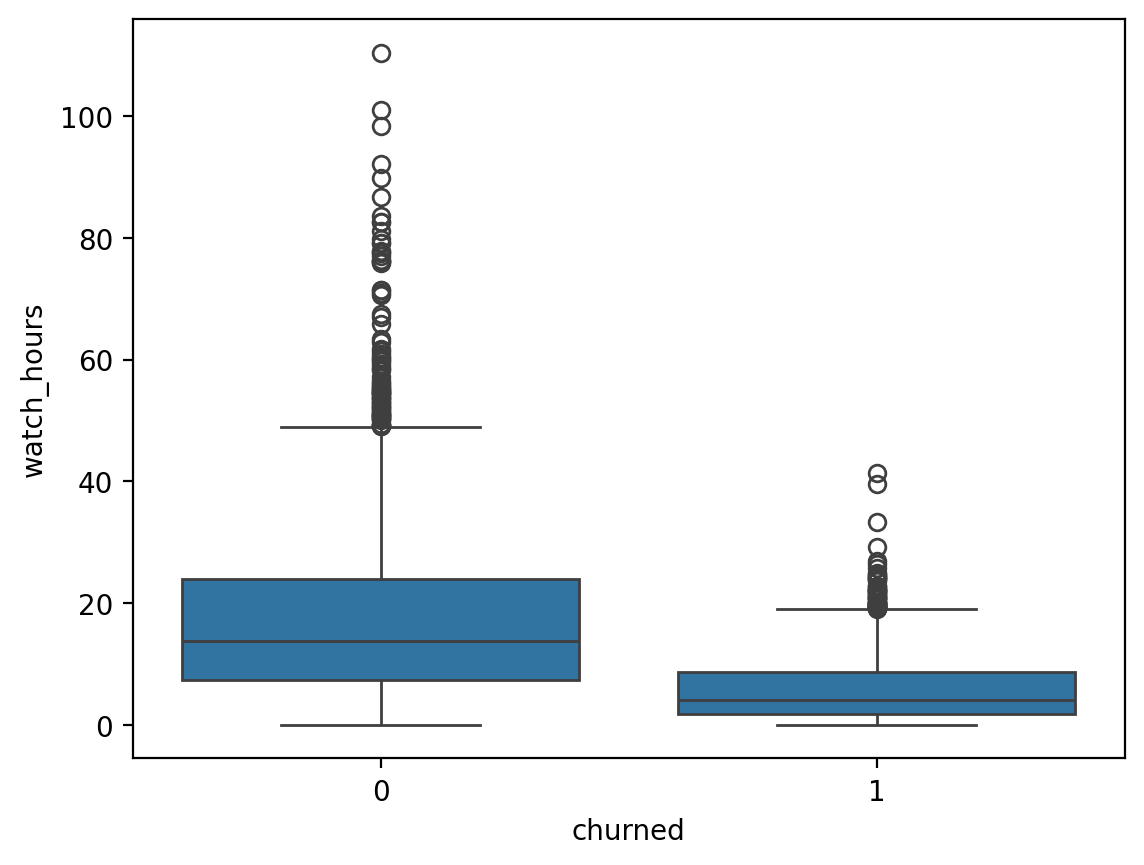

In [107]:
sns.boxplot(x="churned", y="watch_hours", data=df)

CLV = £240
Discount = £10
Subscription price = £20
success_rate = 0.30   (30%)
saved = TP × success_rate
saved = 738 × 0.30 ≈ 221
221 × 240 = £53,040
752 × 10 = £7,520
53,040 − 7,520 = £45,520
If company has 100,000 users:
≈ £3M+ impact